Builds the training dataset for the NER model that extracts print job specifications from customer chat messages, runs exploratory data analysis on it, then trains and evaluates the model. No language model is used to generate or label the data, only manual writing and template substitution.

In [1]:
import json
import random
import os

random.seed(42)  # fixed seed so the dataset is reproducible

OUTPUT_DIR = "../datasets"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Vocabulary lists of Sri Lankan printing terms used to build the manual examples and fill the augmentation templates.

In [2]:
# ---- PRINT_CATEGORY ----
PRINT_CATEGORIES = [
    "business cards", "visiting cards", "flyers", "leaflets", "brochures",
    "banners", "booklets", "invitations", "certificates", "menus",
    "stickers", "labels", "packaging boxes",
]

# ---- QUANTITY ----
QUANTITIES = ["50", "100", "200", "250", "300", "500", "750", "1000", "2000", "5000"]

# ---- SIZE (standard paper / print sizes) ----
SIZES = ["A3", "A4", "A5", "A6"]

# ---- WIDTH / HEIGHT (used together for custom-size requests, in inches) ----
WIDTHS = ["2", "3", "4", "6", "8", "12", "24"]
HEIGHTS = ["3", "4", "6", "9", "10", "18", "36"]

# ---- PAPER_TYPE ----
PAPER_TYPES = [
    "art paper", "bond paper", "bristol board", "ivory board", "sticker paper",
]

# ---- GSM ----
GSM_VALUES = ["80", "100", "120", "250", "300", "350"]

# ---- SIDES ----
SIDES = ["single-sided", "double-sided"]

# ---- COLOUR_MODE ----
COLOUR_MODES = ["black and white", "full colour"]

# ---- FINISHING ----
FINISHINGS = [
    "gloss lamination", "matte lamination", "spot UV", "foil finishing",
    "embossing", "binding", "creasing", "perforation",
]

# ---- PAGE_COUNT ----
PAGE_COUNTS = ["4", "8", "12", "16", "24", "32"]

# ---- DEADLINE ----
DEADLINES = [
    "by Friday", "by Monday", "before next week", "within 3 days",
    "by the end of this month", "before Vesak", "within 2 days", "by tomorrow",
]

# ---- LOCATION (Sri Lankan towns, cities, districts) ----
LOCATIONS = [
    "Colombo", "Kaduwela", "Kandy", "Galle", "Negombo", "Jaffna", "Matara",
    "Kurunegala", "Anuradhapura", "Ratnapura", "Gampaha", "Kalutara",
    "Nuwara Eliya", "Batticaloa", "Trincomalee", "Kotte", "Moratuwa",
    "Maharagama", "Kandy town",
]

# ---- DELIVERY_METHOD ----
DELIVERY_METHODS = ["delivery", "self-collection", "island-wide courier"]

print("Vocabulary loaded.")
print("PRINT_CATEGORIES:", len(PRINT_CATEGORIES))
print("LOCATIONS:", len(LOCATIONS))

Vocabulary loaded.
PRINT_CATEGORIES: 13
LOCATIONS: 19


Helper function that builds the sentence text and its entity spans together, so the character offsets are always correct.

In [3]:
def build_example(parts):
    text = ""
    entities = []
    for part in parts:
        if isinstance(part, tuple):
            value, label = part
            start = len(text)
            text += value
            end = len(text)
            entities.append([start, end, label])
        else:
            text += part
    return [text, {"entities": entities}]

# quick test
example = build_example(["I need ", ("500", "QUANTITY"), " business cards."])
print(example)

['I need 500 business cards.', {'entities': [[7, 10, 'QUANTITY']]}]


Manually written example sentences with varied structure and wording. Some fields are left out on purpose, since real customer messages are often incomplete.

In [4]:
manual = []

manual.append(build_example([
    "I need ", ("500", "QUANTITY"), " ", ("double-sided", "SIDES"),
    " ", ("business cards", "PRINT_CATEGORY"), " on ", ("300", "GSM"),
    " GSM ", ("art paper", "PAPER_TYPE"), " with ", ("matte lamination", "FINISHING"),
    " ", ("before Vesak", "DEADLINE"), ", delivered to ", ("Kaduwela", "LOCATION"), ".",
]))

manual.append(build_example([
    "Can you print ", ("1000", "QUANTITY"), " ", ("flyers", "PRINT_CATEGORY"),
    " in ", ("A5", "SIZE"), " size, ", ("full colour", "COLOUR_MODE"),
    ", ", ("single-sided", "SIDES"), "?",
]))

manual.append(build_example([
    "Looking for ", ("200", "QUANTITY"), " ", ("brochures", "PRINT_CATEGORY"),
    " with ", ("gloss lamination", "FINISHING"), ", ", ("by Friday", "DEADLINE"), ".",
]))

manual.append(build_example([
    "I want a ", ("banner", "PRINT_CATEGORY"), " that is ", ("6", "WIDTH"),
    " feet wide and ", ("3", "HEIGHT"), " feet high for a shop opening in ",
    ("Kandy", "LOCATION"), ".",
]))

manual.append(build_example([
    "Please quote for ", ("100", "QUANTITY"), " ", ("invitations", "PRINT_CATEGORY"),
    " on ", ("ivory board", "PAPER_TYPE"), " with ", ("foil finishing", "FINISHING"), ".",
]))

manual.append(build_example([
    "We need ", ("50", "QUANTITY"), " ", ("certificates", "PRINT_CATEGORY"),
    " printed on ", ("250", "GSM"), " GSM ", ("bristol board", "PAPER_TYPE"),
    ", ", ("full colour", "COLOUR_MODE"), ", ", ("within 3 days", "DEADLINE"), ".",
]))

manual.append(build_example([
    "Need ", ("2000", "QUANTITY"), " ", ("stickers", "PRINT_CATEGORY"),
    " on ", ("sticker paper", "PAPER_TYPE"), ", any size is fine.",
]))

manual.append(build_example([
    "Hi, I need a ", ("menu", "PRINT_CATEGORY"), " booklet, ", ("8", "PAGE_COUNT"),
    " pages, ", ("A4", "SIZE"), " size, ", ("double-sided", "SIDES"),
    ", for our restaurant in ", ("Galle", "LOCATION"), ".",
]))

manual.append(build_example([
    "Can I get ", ("300", "QUANTITY"), " ", ("leaflets", "PRINT_CATEGORY"),
    " printed ", ("by Monday", "DEADLINE"), " with ", ("self-collection", "DELIVERY_METHOD"), "?",
]))

manual.append(build_example([
    "I'm looking for ", ("packaging boxes", "PRINT_CATEGORY"),
    " for a small bakery, around ", ("500", "QUANTITY"), " units.",
]))

manual.append(build_example([
    "We require ", ("750", "QUANTITY"), " ", ("visiting cards", "PRINT_CATEGORY"),
    " in ", ("black and white", "COLOUR_MODE"), " on ", ("100", "GSM"), " GSM paper.",
]))

manual.append(build_example([
    "Please print ", ("12", "PAGE_COUNT"), " page ", ("booklets", "PRINT_CATEGORY"),
    ", ", ("100", "QUANTITY"), " copies, with ", ("binding", "FINISHING"),
    ", to be delivered to ", ("Negombo", "LOCATION"), " via ",
    ("island-wide courier", "DELIVERY_METHOD"), ".",
]))

manual.append(build_example([
    "I need a large ", ("banner", "PRINT_CATEGORY"), ", custom size ",
    ("12", "WIDTH"), " by ", ("4", "HEIGHT"), " feet, ", ("by tomorrow", "DEADLINE"), ".",
]))

manual.append(build_example([
    "Need ", ("labels", "PRINT_CATEGORY"), " for product packaging, about ",
    ("5000", "QUANTITY"), " pieces, on ", ("sticker paper", "PAPER_TYPE"), ".",
]))

manual.append(build_example([
    "Can you do ", ("250", "QUANTITY"), " ", ("business cards", "PRINT_CATEGORY"),
    " with ", ("spot UV", "FINISHING"), " finishing, ", ("A6", "SIZE"), " size?",
]))

manual.append(build_example([
    "I need ", ("400", "QUANTITY"), " ", ("flyers", "PRINT_CATEGORY"),
    " for an event in ", ("Matara", "LOCATION"), ", ", ("before next week", "DEADLINE"), ".",
]))

manual.append(build_example([
    "Please prepare ", ("100", "QUANTITY"), " ", ("certificates", "PRINT_CATEGORY"),
    " for our graduation ceremony, ", ("A4", "SIZE"), " size, with ",
    ("embossing", "FINISHING"), ".",
]))

manual.append(build_example([
    "I want ", ("brochures", "PRINT_CATEGORY"), " with ", ("creasing", "FINISHING"),
    " and ", ("perforation", "FINISHING"), " for a tri-fold layout, ", ("200", "QUANTITY"), " copies.",
]))

manual.append(build_example([
    "Need ", ("1000", "QUANTITY"), " ", ("menus", "PRINT_CATEGORY"),
    " laminated, ", ("double-sided", "SIDES"), ", delivered to ",
    ("Kurunegala", "LOCATION"), " ", ("by the end of this month", "DEADLINE"), ".",
]))

manual.append(build_example([
    "Can I order ", ("50", "QUANTITY"), " ", ("invitations", "PRINT_CATEGORY"),
    " on ", ("bond paper", "PAPER_TYPE"), ", ", ("full colour", "COLOUR_MODE"), "?",
]))

manual.append(build_example([
    "We need ", ("packaging boxes", "PRINT_CATEGORY"), " with ", ("foil finishing", "FINISHING"),
    ", quantity ", ("300", "QUANTITY"), ", for ", ("Jaffna", "LOCATION"), ".",
]))

manual.append(build_example([
    "Print ", ("100", "QUANTITY"), " ", ("A3", "SIZE"), " ", ("banners", "PRINT_CATEGORY"),
    " in ", ("full colour", "COLOUR_MODE"), ".",
]))

manual.append(build_example([
    "I need ", ("stickers", "PRINT_CATEGORY"), " cut to custom shape, ",
    ("3", "WIDTH"), " inches by ", ("3", "HEIGHT"),
    " inches, ", ("2000", "QUANTITY"), " pieces.",
]))

manual.append(build_example([
    "Please quote ", ("600", "QUANTITY"), " ", ("leaflets", "PRINT_CATEGORY"),
    " on ", ("120", "GSM"), " GSM ", ("art paper", "PAPER_TYPE"),
    ", ", ("self-collection", "DELIVERY_METHOD"), " from ", ("Colombo", "LOCATION"), ".",
]))

manual.append(build_example([
    "Hi, need ", ("certificates", "PRINT_CATEGORY"), " for a workshop, ",
    ("80", "QUANTITY"), " copies, ", ("by Friday", "DEADLINE"), ".",
]))

manual.append(build_example([
    "Custom size banner needed, ", ("18", "WIDTH"), " inches by ", ("24", "HEIGHT"),
    " inches, ", ("full colour", "COLOUR_MODE"), ", ", ("100", "QUANTITY"), " units.",
]))

manual.append(build_example([
    "The booklet needs to be ", ("16", "PAGE_COUNT"), " pages, ", ("200", "QUANTITY"),
    " copies, ", ("double-sided", "SIDES"), ", with ", ("binding", "FINISHING"), ".",
]))

manual.append(build_example([
    "Kindly process an order of ", ("500", "QUANTITY"), " ", ("flyers", "PRINT_CATEGORY"),
    " on ", ("100", "GSM"), " GSM paper, ", ("black and white", "COLOUR_MODE"), ".",
]))

manual.append(build_example([
    "URGENT: need ", ("100", "QUANTITY"), " ", ("banners", "PRINT_CATEGORY"),
    " ", ("by tomorrow", "DEADLINE"), " for an event in ", ("Colombo", "LOCATION"), ".",
]))

manual.append(build_example([
    "Please arrange ", ("self-collection", "DELIVERY_METHOD"), " for ", ("300", "QUANTITY"),
    " ", ("stickers", "PRINT_CATEGORY"), " once ready.",
]))

manual.append(build_example([
    "We'd like ", ("island-wide courier", "DELIVERY_METHOD"), " for our order of ",
    ("250", "QUANTITY"), " ", ("certificates", "PRINT_CATEGORY"), " to ", ("Anuradhapura", "LOCATION"), ".",
]))

manual.append(build_example([
    "Dimensions needed: ", ("8", "WIDTH"), " feet wide, ", ("10", "HEIGHT"),
    " feet tall, for a ", ("banner", "PRINT_CATEGORY"), " at our shop.",
]))

manual.append(build_example([
    "Our catalogue booklet is ", ("24", "PAGE_COUNT"), " pages, need ", ("150", "QUANTITY"),
    " printed in ", ("full colour", "COLOUR_MODE"), " on ", ("120", "GSM"), " GSM ", ("art paper", "PAPER_TYPE"), ".",
]))

manual.append(build_example([
    "Could you deliver ", ("2000", "QUANTITY"), " ", ("labels", "PRINT_CATEGORY"),
    " to ", ("Moratuwa", "LOCATION"), " via ", ("delivery", "DELIVERY_METHOD"), "?",
]))

manual.append(build_example([
    "Need a custom banner, ", ("4", "WIDTH"), " by ", ("6", "HEIGHT"),
    " feet, with ", ("spot UV", "FINISHING"), " on the logo.",
]))

manual.append(build_example([
    "Small print job - ", ("brochures", "PRINT_CATEGORY"), ", ", ("50", "QUANTITY"), " copies, ",
    ("4", "PAGE_COUNT"), " pages each, ", ("self-collection", "DELIVERY_METHOD"), ".",
]))

manual.append(build_example([
    "We need our annual report printed, ", ("32", "PAGE_COUNT"), " pages, ", ("30", "QUANTITY"),
    " copies, ", ("A4", "SIZE"), " size, ", ("binding", "FINISHING"), ".",
]))

manual.append(build_example([
    "Good morning, could I get a quote for ", ("100", "QUANTITY"), " ", ("visiting cards", "PRINT_CATEGORY"),
    " with ", ("gloss lamination", "FINISHING"), "?",
]))

manual.append(build_example([
    "Order: ", ("1500", "QUANTITY"), " ", ("stickers", "PRINT_CATEGORY"), ", size ",
    ("2", "WIDTH"), " by ", ("2", "HEIGHT"), " inches, ", ("sticker paper", "PAPER_TYPE"), ".",
]))

manual.append(build_example([
    "For the wedding we need ", ("300", "QUANTITY"), " ", ("invitations", "PRINT_CATEGORY"),
    " on ", ("ivory board", "PAPER_TYPE"), ", ", ("foil finishing", "FINISHING"),
    ", ", ("within 2 days", "DEADLINE"), ".",
]))

manual.append(build_example([
    "Please deliver the ", ("packaging boxes", "PRINT_CATEGORY"), " via ",
    ("island-wide courier", "DELIVERY_METHOD"), " to ", ("Batticaloa", "LOCATION"), ", ", ("500", "QUANTITY"), " units.",
]))

manual.append(build_example([
    "Need a large format print, ", ("24", "WIDTH"), " feet by ", ("6", "HEIGHT"),
    " feet, for the exhibition.",
]))

manual.append(build_example([
    "Our staff handbook is ", ("12", "PAGE_COUNT"), " pages, ", ("40", "QUANTITY"),
    " copies needed, ", ("double-sided", "SIDES"), ", ", ("black and white", "COLOUR_MODE"), ".",
]))

manual.append(build_example([
    "Is ", ("delivery", "DELIVERY_METHOD"), " available for ", ("100", "QUANTITY"),
    " ", ("menus", "PRINT_CATEGORY"), " to ", ("Nuwara Eliya", "LOCATION"), "?",
]))

print(f"Manual examples created: {len(manual)}")

Manual examples created: 44


Sentence templates used to generate augmented examples by substituting random values from the vocabulary lists. Plain string substitution only.

In [5]:
def template_quantity_category_paper(rng):
    return build_example([
        "I need ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " on ",
        (rng.choice(GSM_VALUES), "GSM"), " GSM ",
        (rng.choice(PAPER_TYPES), "PAPER_TYPE"), ".",
    ])

def template_sides_colour_deadline(rng):
    return build_example([
        "Please print ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ", ",
        (rng.choice(SIDES), "SIDES"), ", ",
        (rng.choice(COLOUR_MODES), "COLOUR_MODE"), ", ",
        (rng.choice(DEADLINES), "DEADLINE"), ".",
    ])

def template_finishing_location(rng):
    return build_example([
        "Can you make ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " with ",
        (rng.choice(FINISHINGS), "FINISHING"), ", delivered to ",
        (rng.choice(LOCATIONS), "LOCATION"), "?",
    ])

def template_size_only(rng):
    return build_example([
        "I need ", (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " in ",
        (rng.choice(SIZES), "SIZE"), " size, ",
        (rng.choice(QUANTITIES), "QUANTITY"), " copies.",
    ])

def template_custom_size(rng):
    return build_example([
        "I want a ", (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"),
        " that is ", (rng.choice(WIDTHS), "WIDTH"), " feet wide and ",
        (rng.choice(HEIGHTS), "HEIGHT"), " feet high.",
    ])

def template_pagecount_binding(rng):
    return build_example([
        "Need a ", (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ", ",
        (rng.choice(PAGE_COUNTS), "PAGE_COUNT"), " pages, ",
        (rng.choice(QUANTITIES), "QUANTITY"), " copies, with ",
        (rng.choice(FINISHINGS), "FINISHING"), ".",
    ])

def template_delivery_deadline(rng):
    return build_example([
        "Need ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " ",
        (rng.choice(DEADLINES), "DEADLINE"), ", ",
        (rng.choice(DELIVERY_METHODS), "DELIVERY_METHOD"), ".",
    ])

def template_full_combo(rng):
    return build_example([
        "I need ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(SIDES), "SIDES"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " on ",
        (rng.choice(GSM_VALUES), "GSM"), " GSM ",
        (rng.choice(PAPER_TYPES), "PAPER_TYPE"), " with ",
        (rng.choice(FINISHINGS), "FINISHING"), " ",
        (rng.choice(DEADLINES), "DEADLINE"), ", delivered to ",
        (rng.choice(LOCATIONS), "LOCATION"), ".",
    ])

def template_location_only(rng):
    return build_example([
        "Looking for a print shop near ", (rng.choice(LOCATIONS), "LOCATION"),
        " for ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ".",
    ])

def template_colour_paper(rng):
    return build_example([
        "Print ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " in ",
        (rng.choice(COLOUR_MODES), "COLOUR_MODE"), " on ",
        (rng.choice(PAPER_TYPES), "PAPER_TYPE"), ".",
    ])

def template_short_request(rng):
    return build_example([
        "Need ", (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ", ",
        (rng.choice(QUANTITIES), "QUANTITY"), " pieces.",
    ])

def template_deadline_only(rng):
    return build_example([
        "Can I get ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " ",
        (rng.choice(DEADLINES), "DEADLINE"), "?",
    ])

def template_size_colour_sides(rng):
    return build_example([
        "I need ", (rng.choice(SIZES), "SIZE"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ", ",
        (rng.choice(COLOUR_MODES), "COLOUR_MODE"), ", ",
        (rng.choice(SIDES), "SIDES"), ", ",
        (rng.choice(QUANTITIES), "QUANTITY"), " copies.",
    ])

def template_gsm_finishing_delivery(rng):
    return build_example([
        "Please prepare ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " on ",
        (rng.choice(GSM_VALUES), "GSM"), " GSM paper with ",
        (rng.choice(FINISHINGS), "FINISHING"), ", ",
        (rng.choice(DELIVERY_METHODS), "DELIVERY_METHOD"), ".",
    ])

def template_custom_size_alt(rng):
    return build_example([
        "Dimensions needed: ", (rng.choice(WIDTHS), "WIDTH"), " feet wide, ",
        (rng.choice(HEIGHTS), "HEIGHT"), " feet tall, for a ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ".",
    ])

def template_custom_size_short(rng):
    return build_example([
        "Size: ", (rng.choice(WIDTHS), "WIDTH"), " by ", (rng.choice(HEIGHTS), "HEIGHT"),
        " inches, ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), ".",
    ])

def template_pagecount_alt(rng):
    return build_example([
        "Our ", (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " is ",
        (rng.choice(PAGE_COUNTS), "PAGE_COUNT"), " pages, need ",
        (rng.choice(QUANTITIES), "QUANTITY"), " copies printed in ",
        (rng.choice(COLOUR_MODES), "COLOUR_MODE"), ".",
    ])

def template_delivery_only(rng):
    return build_example([
        "Please arrange ", (rng.choice(DELIVERY_METHODS), "DELIVERY_METHOD"), " for ",
        (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " once ready.",
    ])

def template_delivery_location(rng):
    return build_example([
        "Could you arrange ", (rng.choice(DELIVERY_METHODS), "DELIVERY_METHOD"), " to ",
        (rng.choice(LOCATIONS), "LOCATION"), " for ", (rng.choice(QUANTITIES), "QUANTITY"),
        " ", (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), "?",
    ])

def template_formal_request(rng):
    return build_example([
        "Kindly process an order of ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " on ",
        (rng.choice(GSM_VALUES), "GSM"), " GSM paper, ",
        (rng.choice(COLOUR_MODES), "COLOUR_MODE"), ".",
    ])

def template_urgent_request(rng):
    return build_example([
        "URGENT: need ", (rng.choice(QUANTITIES), "QUANTITY"), " ",
        (rng.choice(PRINT_CATEGORIES), "PRINT_CATEGORY"), " ",
        (rng.choice(DEADLINES), "DEADLINE"), " for an event in ",
        (rng.choice(LOCATIONS), "LOCATION"), ".",
    ])

TEMPLATES = [
    template_quantity_category_paper, template_sides_colour_deadline,
    template_finishing_location, template_size_only, template_custom_size,
    template_pagecount_binding, template_delivery_deadline, template_full_combo,
    template_location_only, template_colour_paper, template_short_request,
    template_deadline_only, template_size_colour_sides, template_gsm_finishing_delivery,
    template_custom_size_alt, template_custom_size_short, template_pagecount_alt,
    template_delivery_only, template_delivery_location, template_formal_request,
    template_urgent_request,
]

print(f"Templates defined: {len(TEMPLATES)}")

Templates defined: 21


In [6]:
# Generate augmented examples.
# The templates that are the main source of WIDTH, HEIGHT, PAGE_COUNT
# and DELIVERY_METHOD get extra samples, since those labels had the
# fewest examples and the lowest recall in earlier training runs.

rng = random.Random(42)
samples_per_template = 20
extra_samples = {
    template_custom_size: samples_per_template + 15,
    template_custom_size_alt: samples_per_template + 15,
    template_custom_size_short: samples_per_template + 15,
    template_pagecount_binding: samples_per_template + 15,
    template_pagecount_alt: samples_per_template + 15,
    template_delivery_only: samples_per_template + 15,
    template_delivery_location: samples_per_template + 15,
}

augmented = []
for template_fn in TEMPLATES:
    count = extra_samples.get(template_fn, samples_per_template)
    for _ in range(count):
        augmented.append(template_fn(rng))

print(f"Augmented examples created: {len(augmented)}")

Augmented examples created: 525


Checks that every entity span is a valid, non-empty range within its sentence before the data is used for training.

In [7]:
def validate_examples(examples):
    errors = []
    for i, (text, ann) in enumerate(examples):
        for start, end, label in ann["entities"]:
            if start < 0 or end > len(text) or start >= end:
                errors.append((i, text, start, end, label, "INVALID RANGE"))
    return errors

all_examples = manual + augmented
print(f"Total before validation: {len(all_examples)}")

errors = validate_examples(all_examples)
if errors:
    print(f"VALIDATION ERRORS FOUND: {len(errors)}")
    for e in errors[:10]:
        print(e)
    raise SystemExit("Fix validation errors before continuing.")
else:
    print("All entity spans validated successfully - no errors.")

Total before validation: 569
All entity spans validated successfully - no errors.


Remove duplicate sentences.

In [8]:
def deduplicate(examples):
    seen = set()
    unique = []
    for text, ann in examples:
        if text not in seen:
            seen.add(text)
            unique.append([text, ann])
    return unique

unique_examples = deduplicate(all_examples)
print(f"Total after dedup: {len(unique_examples)} (removed {len(all_examples) - len(unique_examples)} duplicates)")

Total after dedup: 562 (removed 7 duplicates)


Split the data into train, validation and test sets (70 / 15 / 15).

In [9]:
def split_dataset(examples, train_ratio=0.7, val_ratio=0.15):
    split_rng = random.Random(42)
    shuffled = examples[:]
    split_rng.shuffle(shuffled)

    n = len(shuffled)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train = shuffled[:n_train]
    val = shuffled[n_train:n_train + n_val]
    test = shuffled[n_train + n_val:]
    return train, val, test

train, val, test = split_dataset(unique_examples)
print(f"Train: {len(train)}   Val: {len(val)}   Test: {len(test)}")

Train: 393   Val: 84   Test: 85


Save the dataset files.

In [10]:
with open(f"{OUTPUT_DIR}/train.json", "w", encoding="utf-8") as f:
    json.dump(train, f, indent=2, ensure_ascii=False)
with open(f"{OUTPUT_DIR}/val.json", "w", encoding="utf-8") as f:
    json.dump(val, f, indent=2, ensure_ascii=False)
with open(f"{OUTPUT_DIR}/test.json", "w", encoding="utf-8") as f:
    json.dump(test, f, indent=2, ensure_ascii=False)
with open(f"{OUTPUT_DIR}/full_dataset.json", "w", encoding="utf-8") as f:
    json.dump(unique_examples, f, indent=2, ensure_ascii=False)

print("Saved train.json, val.json, test.json, full_dataset.json to", OUTPUT_DIR)

Saved train.json, val.json, test.json, full_dataset.json to ../datasets


Dataset summary: entity counts and a few example sentences.

In [11]:
def entity_label_counts(examples):
    counts = {}
    for _, ann in examples:
        for _, _, label in ann["entities"]:
            counts[label] = counts.get(label, 0) + 1
    return dict(sorted(counts.items()))

counts = entity_label_counts(unique_examples)
print("Entity label counts (full dataset):")
for label, count in counts.items():
    print(f"  {label:<18} {count}")

print("\nSample annotated sentences:")
for text, ann in unique_examples[:5]:
    print(f"\n  TEXT: {text}")
    for start, end, label in ann["entities"]:
        print(f"    {label:<18} -> '{text[start:end]}'")

Entity label counts (full dataset):
  COLOUR_MODE        122
  DEADLINE           110
  DELIVERY_METHOD    119
  FINISHING          109
  GSM                85
  HEIGHT             109
  LOCATION           128
  PAGE_COUNT         76
  PAPER_TYPE         70
  PRINT_CATEGORY     555
  QUANTITY           490
  SIDES              66
  SIZE               45
  WIDTH              109

Sample annotated sentences:

  TEXT: I need 500 double-sided business cards on 300 GSM art paper with matte lamination before Vesak, delivered to Kaduwela.
    QUANTITY           -> '500'
    SIDES              -> 'double-sided'
    PRINT_CATEGORY     -> 'business cards'
    GSM                -> '300'
    PAPER_TYPE         -> 'art paper'
    FINISHING          -> 'matte lamination'
    DEADLINE           -> 'before Vesak'
    LOCATION           -> 'Kaduwela'

  TEXT: Can you print 1000 flyers in A5 size, full colour, single-sided?
    QUANTITY           -> '1000'
    PRINT_CATEGORY     -> 'flyers'
    SIZE   

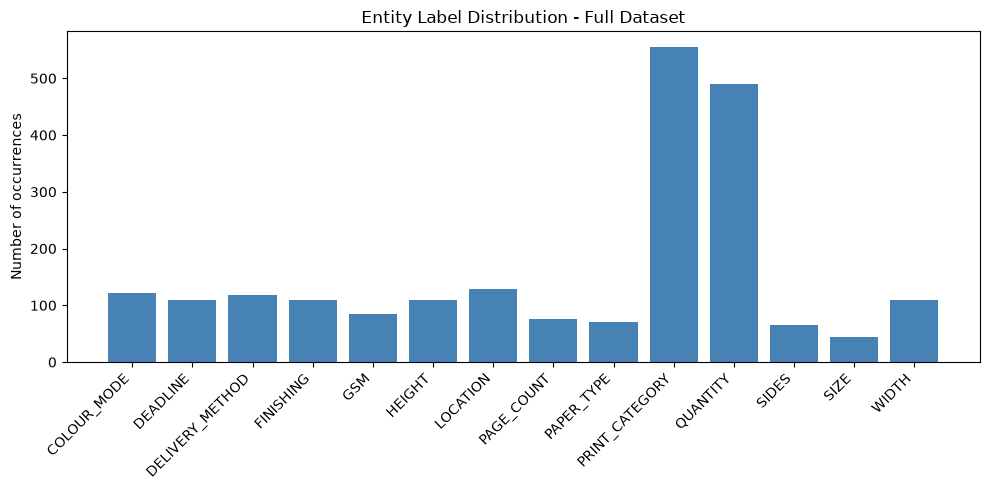

In [12]:
import matplotlib.pyplot as plt

labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of occurrences")
plt.title("Entity Label Distribution - Full Dataset")
plt.tight_layout()
plt.show()

Exploratory data analysis on the dataset built above, before training the model.

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt

DATASET_DIR = "../datasets"

with open(f"{DATASET_DIR}/train.json", encoding="utf-8") as f:
    train_data = json.load(f)
with open(f"{DATASET_DIR}/val.json", encoding="utf-8") as f:
    val_data = json.load(f)
with open(f"{DATASET_DIR}/test.json", encoding="utf-8") as f:
    test_data = json.load(f)
with open(f"{DATASET_DIR}/full_dataset.json", encoding="utf-8") as f:
    full_data = json.load(f)

print("Loaded dataset.")

Loaded dataset.


Dataset overview.

In [14]:
print(f"Train sentences:      {len(train_data)}")
print(f"Validation sentences:  {len(val_data)}")
print(f"Test sentences:        {len(test_data)}")
print(f"Total sentences:       {len(full_data)}")

total_entities = sum(len(ann["entities"]) for _, ann in full_data)
print(f"\nTotal entity annotations: {total_entities}")
print(f"Average entities per sentence: {total_entities / len(full_data):.2f}")

Train sentences:      393
Validation sentences:  84
Test sentences:        85
Total sentences:       562

Total entity annotations: 2193
Average entities per sentence: 3.90


Duplicate rows. Checks for duplicate sentences within the full dataset, and for any sentence that appears in more than one split, since that would leak information between train and test.

In [15]:
texts = [text for text, _ in full_data]
duplicate_count = len(texts) - len(set(texts))
print(f"Duplicate sentences in full dataset: {duplicate_count}")

train_texts = set(text for text, _ in train_data)
val_texts = set(text for text, _ in val_data)
test_texts = set(text for text, _ in test_data)

train_val_overlap = train_texts & val_texts
train_test_overlap = train_texts & test_texts
val_test_overlap = val_texts & test_texts

print(f"Train/Val overlap:  {len(train_val_overlap)}")
print(f"Train/Test overlap: {len(train_test_overlap)}")
print(f"Val/Test overlap:   {len(val_test_overlap)}")

Duplicate sentences in full dataset: 0
Train/Val overlap:  0
Train/Test overlap: 0
Val/Test overlap:   0


Build a table with one row per entity annotation, used for the rest of the analysis.

In [16]:
def build_entity_table(data, split_name):
    rows = []
    for sent_idx, (text, ann) in enumerate(data):
        for start, end, label in ann["entities"]:
            rows.append({
                "split": split_name,
                "sentence_index": sent_idx,
                "label": label,
                "value": text[start:end],
                "span_length": end - start,
                "sentence_word_count": len(text.split()),
            })
    return rows

rows = (
    build_entity_table(train_data, "train")
    + build_entity_table(val_data, "val")
    + build_entity_table(test_data, "test")
)
entity_df = pd.DataFrame(rows)
entity_df.head()

,split,sentence_index,label,value,span_length,sentence_word_count
0,train,0,PRINT_CATEGORY,certificates,12,10
1,train,0,PAGE_COUNT,16,2,10
2,train,0,QUANTITY,200,3,10
3,train,0,FINISHING,matte lamination,16,10
4,train,1,DELIVERY_METHOD,self-collection,15,9


Entity label distribution across the full dataset.

label
COLOUR_MODE        122
DEADLINE           110
DELIVERY_METHOD    119
FINISHING          109
GSM                 85
HEIGHT             109
LOCATION           128
PAGE_COUNT          76
PAPER_TYPE          70
PRINT_CATEGORY     555
QUANTITY           490
SIDES               66
SIZE                45
WIDTH              109
Name: count, dtype: int64


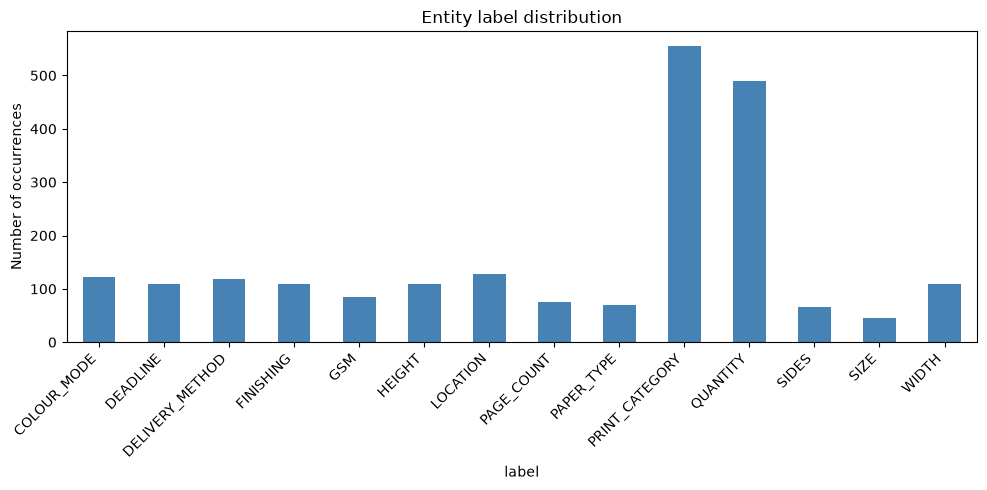

In [17]:
label_counts = entity_df["label"].value_counts().sort_index()
print(label_counts)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar", color="steelblue")
plt.ylabel("Number of occurrences")
plt.title("Entity label distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Sentence length distribution, measured in words.

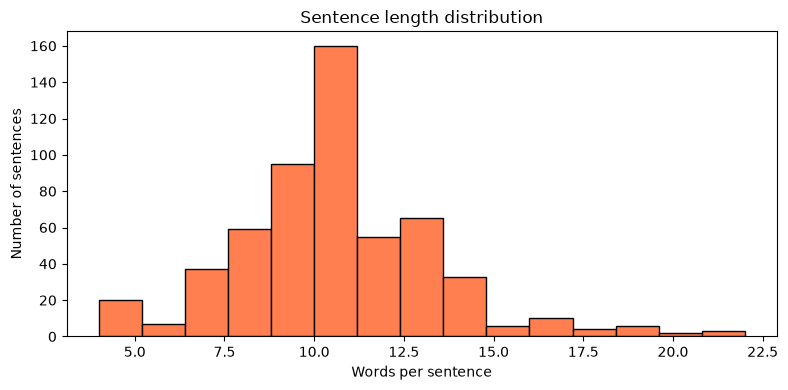

Min words: 4
Max words: 22
Average words: 10.5


In [18]:
sentence_lengths = [len(text.split()) for text, _ in full_data]

plt.figure(figsize=(8, 4))
plt.hist(sentence_lengths, bins=15, color="coral", edgecolor="black")
plt.xlabel("Words per sentence")
plt.ylabel("Number of sentences")
plt.title("Sentence length distribution")
plt.tight_layout()
plt.show()

print(f"Min words: {min(sentence_lengths)}")
print(f"Max words: {max(sentence_lengths)}")
print(f"Average words: {sum(sentence_lengths)/len(sentence_lengths):.1f}")

Number of entities per sentence. Shows how many fields, on average, a customer message contains, which relates directly to the missing-information handling feature.

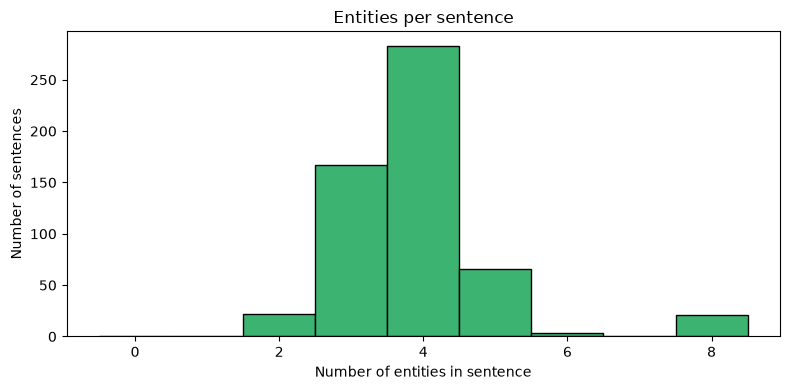

Min entities in a sentence: 2
Max entities in a sentence: 8
Average entities per sentence: 3.90


In [19]:
entities_per_sentence = [len(ann["entities"]) for _, ann in full_data]

plt.figure(figsize=(8, 4))
plt.hist(entities_per_sentence, bins=range(0, max(entities_per_sentence) + 2), color="mediumseagreen", edgecolor="black", align="left")
plt.xlabel("Number of entities in sentence")
plt.ylabel("Number of sentences")
plt.title("Entities per sentence")
plt.tight_layout()
plt.show()

print(f"Min entities in a sentence: {min(entities_per_sentence)}")
print(f"Max entities in a sentence: {max(entities_per_sentence)}")
print(f"Average entities per sentence: {sum(entities_per_sentence)/len(entities_per_sentence):.2f}")

Average entity text length per label, in characters. Longer spans such as finishing types or deadlines are naturally harder for the model to get exactly right than single-token spans such as GSM.

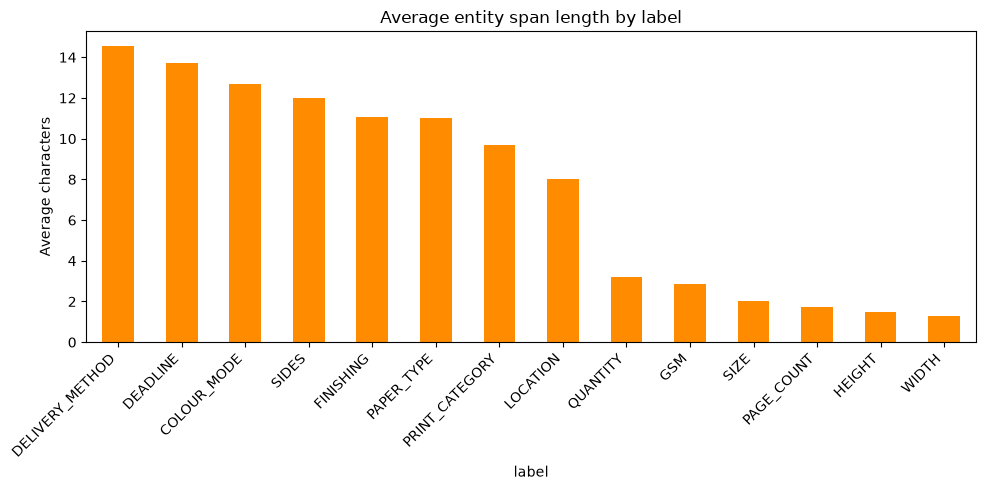

label
DELIVERY_METHOD    14.5
DEADLINE           13.7
COLOUR_MODE        12.7
SIDES              12.0
FINISHING          11.0
PAPER_TYPE         11.0
PRINT_CATEGORY      9.7
LOCATION            8.0
QUANTITY            3.2
GSM                 2.8
SIZE                2.0
PAGE_COUNT          1.7
HEIGHT              1.5
WIDTH               1.3
Name: span_length, dtype: float64


In [20]:
avg_span_length = entity_df.groupby("label")["span_length"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_span_length.plot(kind="bar", color="darkorange")
plt.ylabel("Average characters")
plt.title("Average entity span length by label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(avg_span_length.round(1))

Most common values seen for a few of the key entity labels. Shows how varied or repetitive the vocabulary is for each field.

In [21]:
for label in ["PRINT_CATEGORY", "LOCATION", "PAPER_TYPE", "FINISHING", "DEADLINE"]:
    print(f"\nTop values for {label}:")
    top_values = entity_df[entity_df["label"] == label]["value"].value_counts().head(5)
    print(top_values)


Top values for PRINT_CATEGORY:
value
visiting cards    61
stickers          55
banners           51
certificates      47
invitations       43
Name: count, dtype: int64

Top values for LOCATION:
value
Jaffna         11
Kurunegala     10
Kotte          10
Kandy           9
Trincomalee     8
Name: count, dtype: int64

Top values for PAPER_TYPE:
value
ivory board      18
art paper        18
bristol board    15
bond paper       10
sticker paper     9
Name: count, dtype: int64

Top values for FINISHING:
value
binding             18
foil finishing      17
matte lamination    15
creasing            15
embossing           14
Name: count, dtype: int64

Top values for DEADLINE:
value
by tomorrow                 22
before next week            16
by the end of this month    15
within 2 days               14
by Friday                   12
Name: count, dtype: int64


Entity label distribution compared across the train, validation and test splits, to check the splits are reasonably balanced.

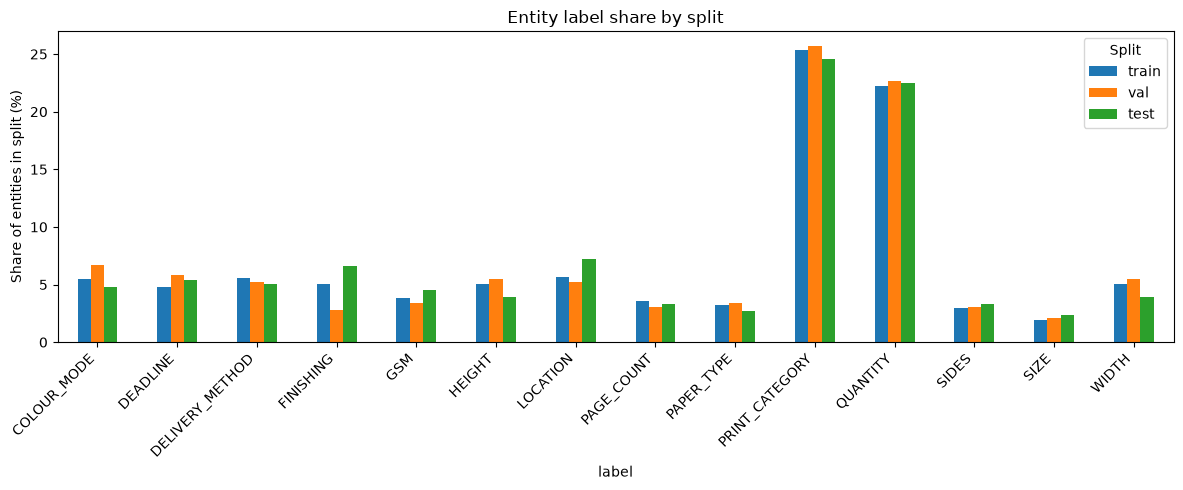

label,COLOUR_MODE,DEADLINE,DELIVERY_METHOD,FINISHING,GSM,HEIGHT,LOCATION,PAGE_COUNT,PAPER_TYPE,PRINT_CATEGORY,QUANTITY,SIDES,SIZE,WIDTH
split,,,,,,,,,,,,,,
test,16,18,17,22,15,13,24,11,9,82,75,11,8,13
train,84,73,85,78,59,78,87,55,50,389,341,45,30,78
val,22,19,17,9,11,18,17,10,11,84,74,10,7,18


In [22]:
split_label_counts = entity_df.groupby(["split", "label"]).size().unstack(fill_value=0)
split_label_pct = split_label_counts.div(split_label_counts.sum(axis=1), axis=0) * 100

split_label_pct = split_label_pct[sorted(split_label_pct.columns)]
split_label_pct = split_label_pct.reindex(["train", "val", "test"])

split_label_pct.T.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Share of entities in split (%)")
plt.title("Entity label share by split")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

split_label_counts

Summary. WIDTH, HEIGHT and PAGE_COUNT have the fewest examples and the fewest sentence templates producing them, which is consistent with the lower recall seen for those labels during model evaluation. This points directly at where the dataset should be expanded first if the model needs to improve.

In [23]:
summary = label_counts.sort_values()
print("Labels with the fewest training examples (lowest first):")
print(summary.head(5))

Labels with the fewest training examples (lowest first):
label
SIZE          45
SIDES         66
PAPER_TYPE    70
PAGE_COUNT    76
GSM           85
Name: count, dtype: int64


Train and evaluate the spaCy NER model on the dataset built above. Uses a standard CPU-based spaCy pipeline, no transformers or deep learning architectures.

In [24]:
import json
import os
import sys
import random
import spacy
from spacy.tokens import DocBin

random.seed(42)

DATASET_DIR = "../datasets"
TRAIN_OUTPUT_DIR = "./training_output"
SAVED_MODEL_DIR = "../saved_model/ner_model"

os.makedirs(DATASET_DIR, exist_ok=True)

Make sure spaCy is installed in the same Python environment this notebook is running in. This avoids the common Windows issue where the 'python' or 'python3' command on PATH points to a different install than the one Jupyter is actually using.

In [25]:
!{sys.executable} -m pip install -U spacy --quiet

Load the train, validation and test JSON files saved earlier in this notebook.

In [26]:
with open(f"{DATASET_DIR}/train.json", encoding="utf-8") as f:
    train_data = json.load(f)
with open(f"{DATASET_DIR}/val.json", encoding="utf-8") as f:
    val_data = json.load(f)
with open(f"{DATASET_DIR}/test.json", encoding="utf-8") as f:
    test_data = json.load(f)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 393
Val: 84
Test: 85


Convert the JSON annotations into spaCy's binary format. Any span that fails to align to a token boundary is counted and skipped, so misaligned data would show up here before training.

In [27]:
nlp_blank = spacy.blank("en")

def convert_to_spacy(data, out_path):
    db = DocBin()
    skipped = 0
    for text, ann in data:
        doc = nlp_blank.make_doc(text)
        spans = []
        for start, end, label in ann["entities"]:
            span = doc.char_span(start, end, label=label, alignment_mode="contract")
            if span is None:
                skipped += 1
            else:
                spans.append(span)
        doc.ents = spans
        db.add(doc)
    db.to_disk(out_path)
    print(f"{out_path} saved. docs: {len(data)}  skipped spans: {skipped}")
    return skipped

skipped_train = convert_to_spacy(train_data, f"{DATASET_DIR}/train.spacy")
skipped_val = convert_to_spacy(val_data, f"{DATASET_DIR}/dev.spacy")
skipped_test = convert_to_spacy(test_data, f"{DATASET_DIR}/test.spacy")

total_skipped = skipped_train + skipped_val + skipped_test
if total_skipped > 0:
    print(f"\nWARNING: {total_skipped} spans could not be aligned. Review before training.")
else:
    print("\nAll spans aligned successfully.")

../datasets/train.spacy saved. docs: 393  skipped spans: 0
../datasets/dev.spacy saved. docs: 84  skipped spans: 0
../datasets/test.spacy saved. docs: 85  skipped spans: 0

All spans aligned successfully.


Generate a base spaCy training config. Optimized for efficiency on CPU, no transformer, no pretrained vectors required.

In [28]:
os.makedirs(TRAIN_OUTPUT_DIR, exist_ok=True)

!{sys.executable} -m spacy init config {TRAIN_OUTPUT_DIR}/config.cfg --lang en --pipeline ner --optimize efficiency --force

⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: ner
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
training_output\config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


Train the model. Epochs and patience are capped so training finishes in a reasonable time on this small dataset.

In [ ]:
!{sys.executable} -m spacy train {TRAIN_OUTPUT_DIR}/config.cfg \
    --output {TRAIN_OUTPUT_DIR}/output \
    --paths.train {DATASET_DIR}/train.spacy \
    --paths.dev {DATASET_DIR}/dev.spacy \
    --training.max_epochs 40 \
    --training.patience 800

Load the best checkpoint saved during training.

In [ ]:
best_model_path = f"{TRAIN_OUTPUT_DIR}/output/model-best"
nlp = spacy.load(best_model_path)
print("Loaded model from:", best_model_path)
print("Pipeline components:", nlp.pipe_names)
print("Entity labels:", nlp.get_pipe("ner").labels)

Loaded model from: ./training_output/output/model-best
Pipeline components: ['tok2vec', 'ner']
Entity labels: ('COLOUR_MODE', 'DEADLINE', 'DELIVERY_METHOD', 'FINISHING', 'GSM', 'HEIGHT', 'LOCATION', 'PAGE_COUNT', 'PAPER_TYPE', 'PRINT_CATEGORY', 'QUANTITY', 'SIDES', 'SIZE', 'WIDTH')


Evaluate on the held-out test set: precision, recall and F1, overall and per entity label.

In [ ]:
from spacy.training import Corpus

corpus = Corpus(f"{DATASET_DIR}/test.spacy")
examples = list(corpus(nlp))

# nlp.evaluate() runs the pipeline on each example and scores it in one
# step. Scoring the examples directly with Scorer() would compare
# against un-processed docs and silently give 0 for everything, so
# nlp.evaluate() is the correct call here.
scores = nlp.evaluate(examples)

print(f"Precision: {scores['ents_p']*100:.2f}%")
print(f"Recall:    {scores['ents_r']*100:.2f}%")
print(f"F1 Score:  {scores['ents_f']*100:.2f}%")

print("\nPer-entity performance:")
print(f"{'LABEL':<18}{'P':>8}{'R':>8}{'F1':>8}")
per_type = scores["ents_per_type"]
for label in sorted(per_type.keys()):
    p = per_type[label]["p"] * 100
    r = per_type[label]["r"] * 100
    f = per_type[label]["f"] * 100
    print(f"{label:<18}{p:>8.2f}{r:>8.2f}{f:>8.2f}")

Precision: 99.70%
Recall:    99.70%
F1 Score:  99.70%

Per-entity performance:
LABEL                    P       R      F1
COLOUR_MODE         100.00  100.00  100.00
DEADLINE            100.00  100.00  100.00
DELIVERY_METHOD     100.00  100.00  100.00
FINISHING           100.00  100.00  100.00
GSM                 100.00  100.00  100.00
HEIGHT              100.00   92.31   96.00
LOCATION            100.00  100.00  100.00
PAGE_COUNT          100.00  100.00  100.00
PAPER_TYPE          100.00  100.00  100.00
PRINT_CATEGORY      100.00  100.00  100.00
QUANTITY            100.00  100.00  100.00
SIDES               100.00  100.00  100.00
SIZE                100.00  100.00  100.00
WIDTH                92.86  100.00   96.30


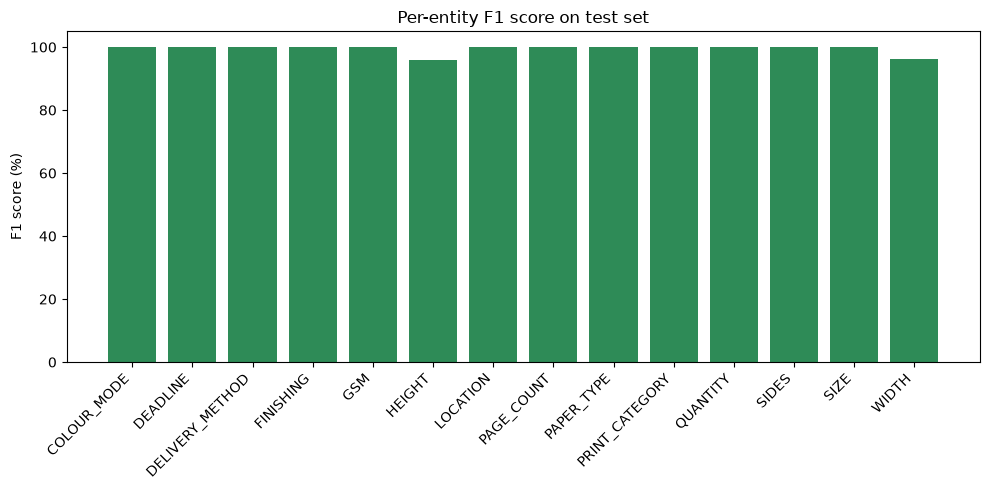

In [ ]:
import matplotlib.pyplot as plt

labels = sorted(per_type.keys())
f1_scores = [per_type[l]["f"] * 100 for l in labels]

plt.figure(figsize=(10, 5))
plt.bar(labels, f1_scores, color="seagreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 score (%)")
plt.title("Per-entity F1 score on test set")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Test the model on new sentences that were not part of the dataset at all, written in different phrasing than the training templates. This gives a more honest sense of real-world generalization than the test set score above, since the test set shares the same template patterns as the training data.

In [ ]:
unseen_examples = [
    "Hey, could you do 350 flyers, glossy, need them by next Wednesday for our Colombo branch?",
    "looking for a place that prints wedding invitations, maybe 150 of them, ivory board if possible",
    "quick question - can I get black and white photocopies of a 20 page booklet, 30 sets?",
    "need banners for a cricket match sponsor, two of them, big ones, want delivery to Galle",
    "whats the price for 1000 stickers water resistant type",
]

for text in unseen_examples:
    doc = nlp(text)
    print(f"\nTEXT: {text}")
    if doc.ents:
        for ent in doc.ents:
            print(f"  {ent.label_:<18} -> '{ent.text}'")
    else:
        print("  (no entities found)")


TEXT: Hey, could you do 350 flyers, glossy, need them by next Wednesday for our Colombo branch?
  QUANTITY           -> '350'
  PRINT_CATEGORY     -> 'flyers'
  DEADLINE           -> 'by next Wednesday'
  QUANTITY           -> 'Colombo'

TEXT: looking for a place that prints wedding invitations, maybe 150 of them, ivory board if possible
  PRINT_CATEGORY     -> 'invitations'
  QUANTITY           -> '150'
  PAPER_TYPE         -> 'ivory board'
  FINISHING          -> 'possible'

TEXT: quick question - can I get black and white photocopies of a 20 page booklet, 30 sets?
  COLOUR_MODE        -> 'black and white'
  PAGE_COUNT         -> '20'
  QUANTITY           -> '30'

TEXT: need banners for a cricket match sponsor, two of them, big ones, want delivery to Galle
  PRINT_CATEGORY     -> 'banners'
  DELIVERY_METHOD    -> 'delivery'
  LOCATION           -> 'Galle'

TEXT: whats the price for 1000 stickers water resistant type
  DEADLINE           -> 's the price'
  QUANTITY           -> '1000

Simple error analysis: compare predicted entities against the gold-standard entities on the test set and list any sentences where they do not match.

In [ ]:
mismatches = 0

for text, ann in test_data:
    gold_ents = set((s, e, l) for s, e, l in ann["entities"])
    doc = nlp(text)
    pred_ents = set((ent.start_char, ent.end_char, ent.label_) for ent in doc.ents)

    if gold_ents != pred_ents:
        mismatches += 1
        print(f"\nTEXT: {text}")
        missed = gold_ents - pred_ents
        extra = pred_ents - gold_ents
        for s, e, l in missed:
            print(f"  MISSED   {l:<18} -> '{text[s:e]}'")
        for s, e, l in extra:
            print(f"  WRONG    {l:<18} -> '{text[s:e]}'")

print(f"\n{mismatches} out of {len(test_data)} test sentences had at least one mismatch.")


TEXT: Custom size banner needed, 18 inches by 24 inches, full colour, 100 units.
  MISSED   HEIGHT             -> '24'
  WRONG    WIDTH              -> '24'

1 out of 85 test sentences had at least one mismatch.


Save the final trained pipeline. spaCy saves a full pipeline as a folder (tokenizer, tok2vec, ner components and metadata), not a single file, so this folder is what gets loaded later in Flask with spacy.load().

In [ ]:
import shutil

if os.path.exists(SAVED_MODEL_DIR):
    shutil.rmtree(SAVED_MODEL_DIR)
shutil.copytree(best_model_path, SAVED_MODEL_DIR)

print("Saved final model to:", SAVED_MODEL_DIR)
print("Contents:", os.listdir(SAVED_MODEL_DIR))

Saved final model to: ../saved_model/ner_model
Contents: ['config.cfg', 'meta.json', 'ner', 'tok2vec', 'tokenizer', 'vocab']


Final summary of results for the report.

In [ ]:
print("FINAL NER MODEL RESULTS")
print("Test set size:", len(test_data))
print(f"Overall Precision: {scores['ents_p']*100:.2f}%")
print(f"Overall Recall:    {scores['ents_r']*100:.2f}%")
print(f"Overall F1:        {scores['ents_f']*100:.2f}%")
print(f"\nMismatched test sentences: {mismatches} / {len(test_data)}")
print("\nNote: test set sentences share template patterns with training data,")
print("so this score is likely optimistic compared to real unseen customer messages.")
print("See the unseen-sentence test above for a more realistic check.")

FINAL NER MODEL RESULTS
Test set size: 85
Overall Precision: 99.70%
Overall Recall:    99.70%
Overall F1:        99.70%

Mismatched test sentences: 1 / 85

Note: test set sentences share template patterns with training data,
so this score is likely optimistic compared to real unseen customer messages.
See the unseen-sentence test above for a more realistic check.
